# Make a map and zonal plot of the average $R^2$

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [2]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

In [3]:
%%time

# takes about 55 sec

# start with one year and lsm and add a coordinate for the year
year = 1990
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1991,2023,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 21.1 s, sys: 27.4 s, total: 48.5 s
Wall time: 56.8 s


<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 33)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 264B 1990-01-01 ... 2022-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 274MB 146.0 146.0 ... 212.0 212.0
    SummerEnd     (time, lat, lon) float64 274MB 220.0 220.0 ... 242.0 242.0
    SummerTmax    (time, lat, lon) float64 274MB 174.0 174.0 ... 213.0 213.0
    SummerHeat    (time, lat, lon) float64 274MB 1.84e+04 1.84e+04 ... 8.191e+03
    SummerLength  (time, lat, lon) float64 274MB 75.0 75.0 75.0 ... 31.0 31.0
    SummerRMSE    (time, lat, lon) float64 274MB 7.937 7.937 ... 4.992 4.992
    SummerR2      (time, lat, lon) float64 274MB 0.5064 0.5064 ... 0.7734 0.7734
    SummerMeanT   (time, lat, lon) float64 274MB 245.3 245.3 ... 272.9 272.9
    lsm           (time, lat, lon) float64 274MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

In [14]:
# find weights (this is a regular grid so we can use cos(latitude))
# weights = np.cos(np.deg2rad(ds.lat))
# weights.name = "weights"
# take the weighted spatial mean since the latitude range of the region of interest is large
mean_glob_r2 = ds.SummerR2.mean(dim=['time'])
mean_glob_r2.attrs['long_name'] = "R-squared"
mean_glob_r2.attrs['units'] = "Variance Explained"

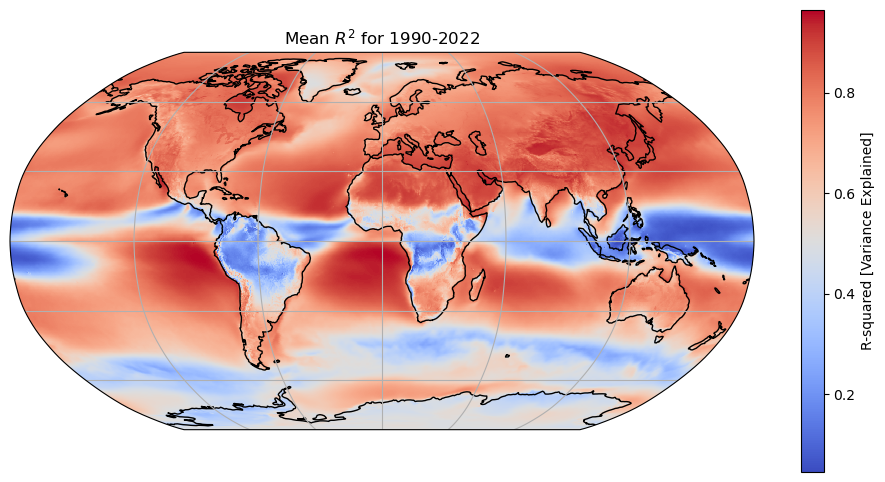

In [15]:
# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

#ds_full.SummerR2.where(ds_full.SummerR2 > 0.2).plot(
mean_glob_r2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=0,
    #vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Mean $R^{2}$ for 1990-2022")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\g'
<>:20: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_23317/2922560286.py:20: SyntaxWarning: invalid escape sequence '\g'
  plt.title("Mean $R^{2}$ for $R^{2} \geq 0.3$ 1990-2022")


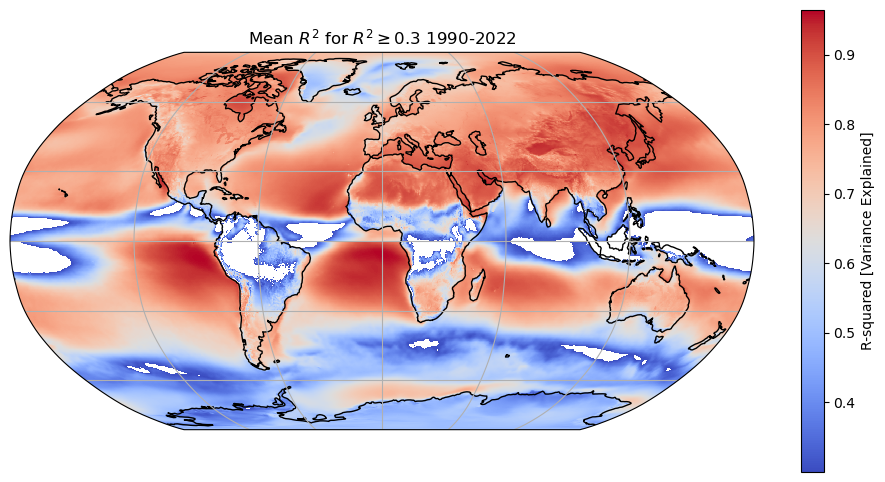

In [16]:
# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

#ds_full.SummerR2.where(ds_full.SummerR2 > 0.2).plot(
mean_glob_r2.where(mean_glob_r2.values >= 0.3).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=0,
    #vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Mean $R^{2}$ for $R^{2} \geq 0.3$ 1990-2022")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()

## Also for baseline years

In [19]:
%%time

# takes about 40 sec

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm)
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1991,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 15.4 s, sys: 17.5 s, total: 32.9 s
Wall time: 39 s


<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 30)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 240B 1961-01-01 ... 1990-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerEnd     (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerTmax    (time, lat, lon) float64 249MB 179.0 179.0 ... 203.0 203.0
    SummerHeat    (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerLength  (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerRMSE    (time, lat, lon) float64 249MB 6.906 6.906 ... 5.745 5.745
    SummerR2      (time, lat, lon) float64 249MB 0.5105 0.5105 ... 0.6524 0.6524
    lsm           (time, lat, lon) float64 249MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 249MB nan nan nan nan ... 0.0 0.0 0.0

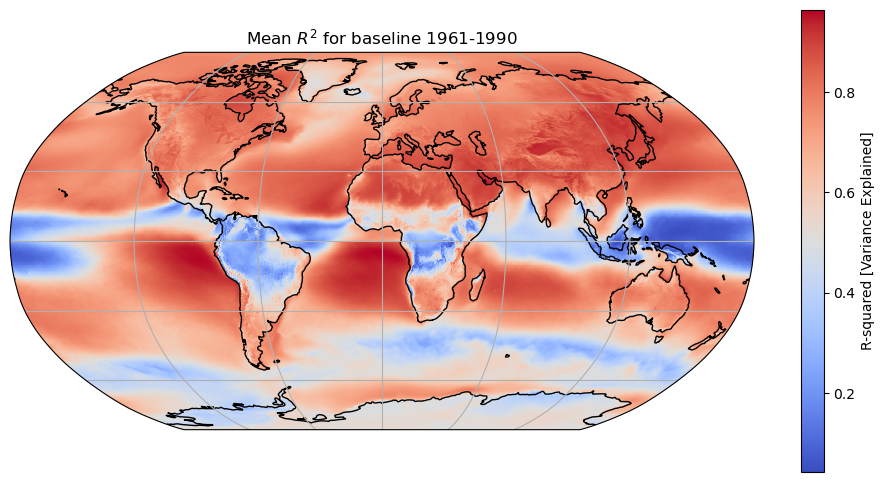

In [20]:
mean_glob_base_r2 = ds_base.SummerR2.mean(dim=['time'])
mean_glob_base_r2.attrs['long_name'] = "R-squared"
mean_glob_base_r2.attrs['units'] = "Variance Explained"

# Global summer R2 from polynomial fits
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

#ds_full.SummerR2.where(ds_full.SummerR2 > 0.2).plot(
mean_glob_base_r2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=0,
    #vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Mean $R^{2}$ for baseline 1961-1990")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()

## where is the stddev lower than 0.1?

In [21]:
sd_glob_base_r2 = ds_base.SummerR2.std(dim=['time'])
sd_glob_base_r2.attrs['long_name'] = "R-squared"
sd_glob_base_r2.attrs['units'] = "Variance Explained"

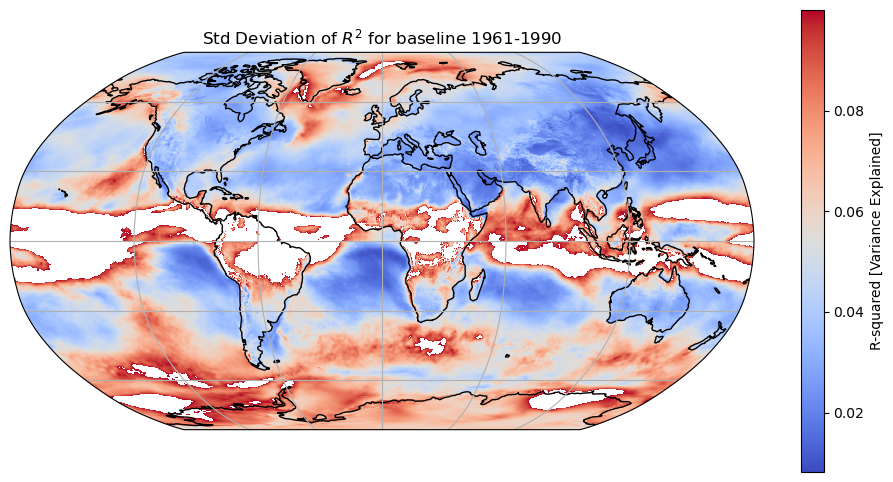

In [23]:
# Global summer R2 from polynomial fits
# where is the stddev lower than 0.1?
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

sd_glob_base_r2.where(sd_glob_base_r2.values <= 0.1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=0,
    #vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Std Deviation of $R^{2}$ for baseline 1961-1990")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()